In [1]:
### set up the notebook
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import scipy.signal
from scipy.interpolate import griddata
import dask as da

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
np.set_printoptions(linewidth=100) 

plt.rcParams.update({'font.size': 14})

da.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
### Function to calculate PSD 

def cal_psd(access, sam_int):
    access_psd_all = []
    for j in range(len(access.time.values)):
        access_day = access.isel(time=j)
        access_psd_day = []
        for i in range(len(access_day.num_pixels)):
            data = access_day.ZWD.values[:,i]*100
            data_mean = np.nanmean(data)
            data[np.isnan(data)] = data_mean
            f, Pxx = scipy.signal.welch(data, fs=1/sam_int, window='hanning', detrend='constant', scaling='density')
            access_psd_day.append(Pxx)
        access_psd_all.append(np.nanmean(np.array(access_psd_day), axis=0))
    return f, np.array(access_psd_all)

In [3]:
### load the ACCESS and SWOT data and trim

# load ACCESS
bs_6_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_bst_6_at_SWOT.nc')
bs_19_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_bst_19_at_SWOT.nc')
alb_8_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_alb_8_at_SWOT.nc')
alb_21_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_alb_21_at_SWOT.nc')
crp_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_crp_at_SWOT.nc')
dvr_ZWD = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_dvr_at_SWOT.nc')

# load SWOT
swot_bs_6 = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_006_PGC0_02_bst.nc')
swot_bs_19 = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_019_PGC0_02_bst.nc')
swot_alb_8 = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_008_PGC0_02_alb.nc')
swot_alb_21 = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_021_PGC0_02_alb.nc')
swot_dvr = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_019_PGC0_02_dvr.nc')
swot_crp = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_006_PGC0_02_crp.nc')

# trim SWOT to ocean areas
swot_bs_6 = swot_bs_6.sel(num_lines=slice(7138, 7212), drop=True)
swot_bs_19 = swot_bs_19.sel(num_lines=slice(None, 2746), drop=True)
swot_alb_8 = swot_alb_8.sel(num_lines=slice(6900, None), drop=True)
swot_alb_21 = swot_alb_21.sel(num_lines=slice(None, 2960), drop=True)
swot_crp = swot_crp.sel(num_lines=slice(5400, 5850), drop=True)
swot_dvr = swot_dvr.sel(num_lines=slice(3848, None), drop=True)

# trim ACCESS to match
bs_6_ZWD = bs_6_ZWD.sel(num_lines=slice(7138, 7212), drop=True)
bs_19_ZWD = bs_19_ZWD.sel(num_lines=slice(None, 2746), drop=True)
alb_8_ZWD = alb_8_ZWD.sel(num_lines=slice(6900, 7018), drop=True)
alb_21_ZWD = alb_21_ZWD.sel(num_lines=slice(2847, 2960), drop=True)
crp_ZWD = crp_ZWD.sel(num_lines=slice(5711, 5850), drop=True)
dvr_ZWD = dvr_ZWD.sel(num_lines=slice(3848, None), drop=True)


In [4]:
### drop SWOT cycles where there is no ACCESS data

swot_bs_6 = swot_bs_6.drop_isel(cycle=3)
swot_bs_19 = swot_bs_19.drop_isel(cycle=59)
swot_dvr = swot_dvr.drop_isel(cycle=59)
swot_crp = swot_crp.drop_isel(cycle=3)
swot_crp = swot_crp.drop_isel(cycle=87)

In [5]:
### rename SWOT dims to combine datasets

# rename for consistency with ACCESS
swot_bs_6 = swot_bs_6.rename({'time':'all_times'})
swot_bs_6 = swot_bs_6.rename_dims({'cycle': 'time'})
swot_bs_19 = swot_bs_19.rename({'time':'all_times'})
swot_bs_19 = swot_bs_19.rename_dims({'cycle': 'time'})
swot_alb_8 = swot_alb_8.rename({'time':'all_times'})
swot_alb_8 = swot_alb_8.rename_dims({'cycle': 'time'})
swot_alb_21 = swot_alb_21.rename({'time':'all_times'})
swot_alb_21 = swot_alb_21.rename_dims({'cycle': 'time'})
swot_crp = swot_crp.rename({'time':'all_times'})
swot_crp = swot_crp.rename_dims({'cycle': 'time'})
swot_dvr = swot_dvr.rename({'time':'all_times'})
swot_dvr = swot_dvr.rename_dims({'cycle': 'time'})

# calculate resids and save 
bs_6_ZWD_rad = bs_6_ZWD.copy()
bs_6_ZWD_mod = bs_6_ZWD.copy()
bs_6_ZWD_rad['ZWD'] = bs_6_ZWD.ZWD + swot_bs_6.rad_wet_tropo_cor
bs_6_ZWD_mod['ZWD'] = bs_6_ZWD.ZWD + swot_bs_6.model_wet_tropo_cor
bs_6_ZWD_rad = bs_6_ZWD_rad.load()
bs_6_ZWD_mod = bs_6_ZWD_mod.load()

bs_19_ZWD_rad = bs_19_ZWD.copy()
bs_19_ZWD_mod = bs_19_ZWD.copy()
bs_19_ZWD_rad['ZWD'] = bs_19_ZWD.ZWD + swot_bs_19.rad_wet_tropo_cor
bs_19_ZWD_mod['ZWD'] = bs_19_ZWD.ZWD + swot_bs_19.model_wet_tropo_cor
bs_19_ZWD_rad = bs_19_ZWD_rad.load()
bs_19_ZWD_mod = bs_19_ZWD_mod.load()

alb_8_ZWD_rad = alb_8_ZWD.copy()
alb_8_ZWD_mod = alb_8_ZWD.copy()
alb_8_ZWD_rad['ZWD'] = alb_8_ZWD.ZWD + swot_alb_8.rad_wet_tropo_cor
alb_8_ZWD_mod['ZWD'] = alb_8_ZWD.ZWD + swot_alb_8.model_wet_tropo_cor
alb_8_ZWD_rad = alb_8_ZWD_rad.load()
alb_8_ZWD_mod = alb_8_ZWD_mod.load()

alb_21_ZWD_rad = alb_21_ZWD.copy()
alb_21_ZWD_mod = alb_21_ZWD.copy()
alb_21_ZWD_rad['ZWD'] = alb_21_ZWD.ZWD + swot_alb_21.rad_wet_tropo_cor
alb_21_ZWD_mod['ZWD'] = alb_21_ZWD.ZWD + swot_alb_21.model_wet_tropo_cor
alb_21_ZWD_rad = alb_21_ZWD_rad.load()
alb_21_ZWD_mod = alb_21_ZWD_mod.load()

crp_ZWD_rad = crp_ZWD.copy()
crp_ZWD_mod = crp_ZWD.copy()
crp_ZWD_rad['ZWD'] = crp_ZWD.ZWD + swot_crp.rad_wet_tropo_cor
crp_ZWD_mod['ZWD'] = crp_ZWD.ZWD + swot_crp.model_wet_tropo_cor
crp_ZWD_rad = crp_ZWD_rad.load()
crp_ZWD_mod = crp_ZWD_mod.load()

dvr_ZWD_rad = dvr_ZWD.copy()
dvr_ZWD_mod = dvr_ZWD.copy()
dvr_ZWD_rad['ZWD'] = dvr_ZWD.ZWD + swot_dvr.rad_wet_tropo_cor
dvr_ZWD_mod['ZWD'] = dvr_ZWD.ZWD + swot_dvr.model_wet_tropo_cor
dvr_ZWD_rad = dvr_ZWD_rad.load()
dvr_ZWD_mod = dvr_ZWD_mod.load()

In [6]:
### calculate the resid PSD

# Calculate PSD for bs_6
bs_6_freq, bs_6_psd = cal_psd(bs_6_ZWD, 2)
bs_6_freq_mod, bs_6_mod_psd = cal_psd(bs_6_ZWD_mod, 2)

# Calculate PSD for bs_19
bs_19_freq, bs_19_psd = cal_psd(bs_19_ZWD, 2)
bs_19_freq_mod, bs_19_mod_psd = cal_psd(bs_19_ZWD_mod, 2)

# Calculate PSD for alb_8
alb_8_freq, alb_8_psd = cal_psd(alb_8_ZWD, 2)
alb_8_freq_mod, alb_8_mod_psd = cal_psd(alb_8_ZWD_mod, 2)

# Calculate PSD for alb_21
alb_21_freq, alb_21_psd = cal_psd(alb_21_ZWD, 2)
alb_21_freq_mod, alb_21_mod_psd = cal_psd(alb_21_ZWD_mod, 2)

# Calculate PSD for crp
crp_freq, crp_psd = cal_psd(crp_ZWD, 2)
crp_freq_mod, crp_mod_psd = cal_psd(crp_ZWD_mod, 2)

# Calculate PSD for dvr
dvr_freq, dvr_psd = cal_psd(dvr_ZWD, 2)
dvr_freq_mod, dvr_mod_psd = cal_psd(dvr_ZWD_mod, 2)


/tmp/ipykernel_387693/2451103766.py:10: RuntimeWarning: Mean of empty slice
  data_mean = np.nanmean(data)
/working/hendreya/python_venvs/for_xarray/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 256 is greater than input length  = 75, using nperseg = 75
  warnings.warn('nperseg = {0:d} is greater than input length '
/tmp/ipykernel_387693/2451103766.py:14: RuntimeWarning: Mean of empty slice
  access_psd_all.append(np.nanmean(np.array(access_psd_day), axis=0))
/working/hendreya/python_venvs/for_xarray/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 256 is greater than input length  = 157, using nperseg = 157
  warnings.warn('nperseg = {0:d} is greater than input length '
/working/hendreya/python_venvs/for_xarray/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 256 is greater than input length  = 119, using nperseg = 119
  warnings.warn('nperseg = {0:d} is greater than input length '
/w

/tmp/ipykernel_387693/2802902873.py:38: RuntimeWarning: divide by zero encountered in true_divide
  ax[0,0].loglog(1/crp_freq_mod, crp_mod_psd_mean, label='Residual wet troposphere', c='C0', lw=3)
/tmp/ipykernel_387693/2802902873.py:39: RuntimeWarning: divide by zero encountered in true_divide
  ax[1,0].loglog(1/alb_freq_mod, alb_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3)
/tmp/ipykernel_387693/2802902873.py:40: RuntimeWarning: divide by zero encountered in true_divide
  ax[0,1].loglog(1/dvr_freq_mod, dvr_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3)
/tmp/ipykernel_387693/2802902873.py:41: RuntimeWarning: divide by zero encountered in true_divide
  ax[1,1].loglog(1/bs_freq_mod, bs_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3)


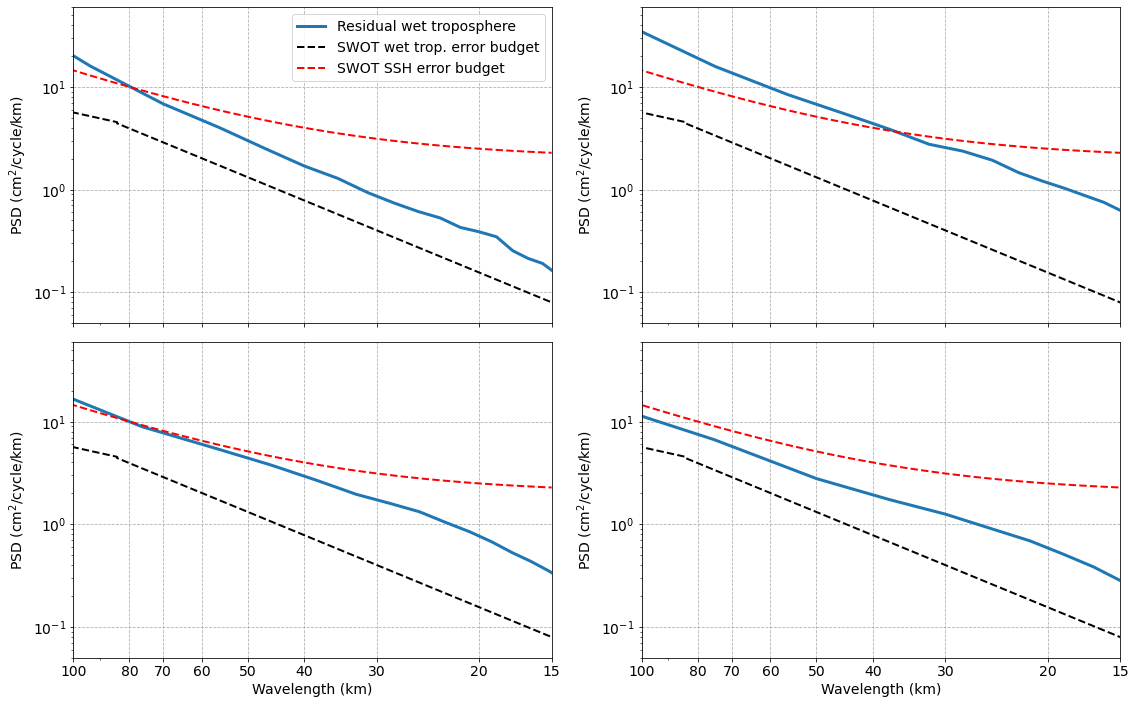

In [7]:
### Plot PSD with SWOT error budget

# define trop error from SWOT error doc
f_1 = np.array((1e-3, 0.0049))
trop_error_1 = 0.205*f_1**(-0.7911)
f_2 = np.array((0.0049, 0.0119))
trop_error_2 = 0.0179*f_2**(-1.2492)
f_3 = np.array((0.0119, 1/4))
trop_error_3 = 1.448e-4*f_3**(-2.33)
trop_error = np.concatenate((trop_error_1, trop_error_2, trop_error_3))
f_trop_error = np.concatenate((f_1, f_2, f_3))
f_ssh_error = np.linspace(1/1000, 1/15, 100)
ssh_error = 2+1.25e-3*f_ssh_error**(-2)


### calculate the mean of each PSD

bs_6_mod_psd_mean = np.nanmean(bs_6_mod_psd, axis=0)
bs_19_mod_psd_mean = np.nanmean(bs_19_mod_psd, axis=0)
alb_8_mod_psd_mean = np.nanmean(alb_8_mod_psd, axis=0)
alb_21_mod_psd_mean = np.nanmean(alb_21_mod_psd, axis=0)
crp_mod_psd_mean = np.nanmean(crp_mod_psd, axis=0)
dvr_mod_psd_mean = np.nanmean(dvr_mod_psd, axis=0)

# Interpolate bass strait and albany on consistent freq intervals
bs_19_mod_psd_mean_interp = np.interp(bs_6_freq_mod, bs_19_freq_mod, bs_19_mod_psd_mean)
alb_8_mod_psd_mean_interp = np.interp(alb_21_freq_mod, alb_8_freq_mod, alb_8_mod_psd_mean)

# take mean of both
bs_freq_mod = bs_6_freq_mod
bs_mod_psd_mean = (bs_19_mod_psd_mean_interp + bs_6_mod_psd_mean)/2
alb_freq_mod = alb_21_freq_mod
alb_mod_psd_mean = (alb_8_mod_psd_mean_interp + alb_21_mod_psd_mean)/2


fig, ax = plt.subplots(2, 2, figsize=(16,10), sharex = True)

ax[0,0].loglog(1/crp_freq_mod, crp_mod_psd_mean, label='Residual wet troposphere', c='C0', lw=3)    
ax[1,0].loglog(1/alb_freq_mod, alb_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3)  
ax[0,1].loglog(1/dvr_freq_mod, dvr_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3) 
ax[1,1].loglog(1/bs_freq_mod, bs_mod_psd_mean, label='ACCESS-C wet trop', c='C0', lw=3)

for i in range(2):
    for j in range(2):
        ax[i,j].loglog(1/f_trop_error, trop_error, 'k', lw=2, label='SWOT wet trop. error budget', ls='--')
        ax[i,j].loglog(1/f_ssh_error, ssh_error, linewidth=2, c='red', label='SWOT SSH error budget', ls='--')
        ax[i,j].invert_xaxis()
        ax[i,j].set_xlim(100, 15)
        ax[i,j].set_ylim(5e-2, 6e1)
        ax[i,j].set_xticks([100, 80, 70, 60, 50, 40, 30, 20, 15])
        ax[i,j].set_xticklabels(['100', '80', '70', '60','50', '40', '30', '20', '15'])
        ax[i,j].set_ylabel('PSD (cm$^2$/cycle/km)')
        ax[1,j].set_xlabel('Wavelength (km)')
        ax[i,j].grid(linestyle='--')
ax[0,0].legend()
plt.tight_layout()
plt.show()

In [9]:
### integrate the PSD from 84 to 15 km

x = np.linspace(1/84, 1/15, 1000)
trop_error_3 = 1.448e-4*x**(-2.33)
area = np.trapz(trop_error_3, x)
print('trop error budget: %0.2f cm' % np.sqrt(area))

bs_psd_interp = np.interp(x, bs_freq_mod, bs_mod_psd_mean)
alb_psd_interp = np.interp(x, alb_freq_mod, alb_mod_psd_mean)
crp_psd_interp = np.interp(x, crp_freq_mod, crp_mod_psd_mean)
dvr_psd_interp = np.interp(x, dvr_freq_mod, dvr_mod_psd_mean)

bs_area = np.trapz(bs_psd_interp, x)
alb_area = np.trapz(alb_psd_interp, x)
crp_area = np.trapz(crp_psd_interp, x)
dvr_area = np.trapz(dvr_psd_interp, x)

print('bs: %0.2f cm' % np.sqrt(bs_area))
print('alb: %0.2f cm' % np.sqrt(alb_area))
print('crp: %0.2f cm' % np.sqrt(crp_area))
print('dvr: %0.2f cm' % np.sqrt(dvr_area))

trop error budget: 0.19 cm
bs: 0.30 cm
alb: 0.35 cm
crp: 0.29 cm
dvr: 0.45 cm


In [44]:
### calculate RMSE between ACCESS and SWOT radiometer, and ACCESS and ECMWF

bs_rad_resid = np.array((list(bs_6_ZWD_rad['ZWD'].values.flatten()) + list(bs_19_ZWD_rad['ZWD'].values.flatten())))
bs_mod_resid = np.array((list(bs_6_ZWD_mod['ZWD'].values.flatten()) + list(bs_19_ZWD_mod['ZWD'].values.flatten())))
alb_rad_resid = np.array((list(alb_8_ZWD_rad['ZWD'].values.flatten()) + list(alb_21_ZWD_rad['ZWD'].values.flatten())))
alb_mod_resid = np.array((list(alb_8_ZWD_mod['ZWD'].values.flatten()) + list(alb_21_ZWD_mod['ZWD'].values.flatten())))
crp_rad_resid = crp_ZWD_rad['ZWD'].values.flatten()
crp_mod_resid = crp_ZWD_mod['ZWD'].values.flatten()
dvr_rad_resid = dvr_ZWD_rad['ZWD'].values.flatten()
dvr_mod_resid = dvr_ZWD_mod['ZWD'].values.flatten()

print('bs rad RMSE: %0.3f m' % np.sqrt(np.nanmean(bs_rad_resid**2)))
print('alb rad RMSE: %0.3f m' % np.sqrt(np.nanmean(alb_rad_resid**2)))
print('crp rad RMSE: %0.3f m' % np.sqrt(np.nanmean(crp_rad_resid**2)))
print('dvr rad RMSE: %0.3f m' % np.sqrt(np.nanmean(dvr_rad_resid**2)))
print('')
print('bs mod RMSE: %0.3f m' % np.sqrt(np.nanmean(bs_mod_resid**2)))
print('alb mod RMSE: %0.3f m' % np.sqrt(np.nanmean(alb_mod_resid**2)))
print('crp mod RMSE: %0.3f m' % np.sqrt(np.nanmean(crp_mod_resid**2)))
print('dvr mod RMSE: %0.3f m' % np.sqrt(np.nanmean(dvr_mod_resid**2)))

bs rad RMSE: 0.012 m
alb rad RMSE: 0.011 m
crp rad RMSE: 0.026 m
dvr rad RMSE: 0.017 m

bs mod RMSE: 0.011 m
alb mod RMSE: 0.013 m
crp mod RMSE: 0.023 m
dvr mod RMSE: 0.018 m
